# ***Testing Notebook***

## **Environment Repair and Setup**

In [17]:
import sys
print(f"Current Kernel Python: {sys.executable}")

# Force install compatible versions inside this kernel
%pip install -q scikit-learn==1.5.2 imbalanced-learn==0.12.3 shap torch xlrd openpyxl pandas numpy matplotlib seaborn tqdm

print("Installation complete. PLEASE RESTART YOUR KERNEL NOW (Kernel -> Restart) if you haven't already.")

Current Kernel Python: c:\ProgramData\anaconda3\python.exe
Note: you may need to restart the kernel to use updated packages.
Installation complete. PLEASE RESTART YOUR KERNEL NOW (Kernel -> Restart) if you haven't already.


In [18]:
import os
import random
import logging
import warnings
import gc
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, roc_auc_score, roc_curve

from imblearn.combine import SMOTEENN
import shap
import scipy.stats as stats

warnings.filterwarnings('ignore')

In [19]:
# Configuration
TESTING_MODE = True  # SET TO FALSE FOR FINAL RUN
NUM_EPOCHS = 10 if TESTING_MODE else 100
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def SetSeed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SetSeed(SEED)

for d in ['results/logs', 'results/metrics', 'results/plots', 'results/shap', 'results/models']:
    os.makedirs(d, exist_ok=True)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s', 
                    handlers=[logging.StreamHandler(), logging.FileHandler('results/logs/A3.log')])
logger = logging.getLogger('A3')

## **1. Innovations: Models and Loss Functions**

In [20]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE)
        loss = self.alpha * (1 - pt)**self.gamma * BCE
        return loss.mean()

class AttentionModule(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(hidden_dim, 64), nn.Tanh(), nn.Linear(64, 1))

    def forward(self, x):
        weights = F.softmax(self.attn(x), dim=1)
        context = torch.sum(weights * x, dim=1)
        return context, weights

class AttentionGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn = AttentionModule(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        out, _ = self.gru(x)
        context, weights = self.attn(out)
        logits = self.fc(self.dropout(context))
        return logits

class PaperGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        _, h_n = self.gru(x)
        return self.fc(self.dropout(h_n[-1]))

## **2. Data Preparation**

In [21]:
def LoadData():
    # German
    df_g = pd.read_csv('dataset/german.data-numeric', sep=r'\s+', header=None)
    X_g, y_g = df_g.iloc[:, :-1], np.where(df_g.iloc[:, -1] == 1, 0, 1)
    
    # Australian
    df_a = pd.read_csv('dataset/australian.dat', sep=r'\s+', header=None)
    X_a, y_a = df_a.iloc[:, :-1], df_a.iloc[:, -1].values
    
    # Taiwan
    df_t = pd.read_excel('dataset/default of credit card clients.xls', skiprows=1).drop(columns=['ID'])
    X_t, y_t = df_t.iloc[:, :-1], df_t.iloc[:, -1].values
    
    return (X_g, y_g), (X_a, y_a), (X_t, y_t)

def GetPipeline(name):
    if name == 'australian':
        cat, num = [0, 3, 4, 5, 8, 9, 11], [1, 2, 6, 7, 10, 12, 13]
    elif name == 'taiwan':
        cat, num = [1, 2, 3, 5, 6, 7, 8, 9, 10], [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
    else: return StandardScaler()
    
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer()), ('s', StandardScaler())]), num),
        ('cat', Pipeline([
            ('i', SimpleImputer(strategy='most_frequent')),
            ('e', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ('s', StandardScaler())
        ]), cat)
    ])

## **3. Experimental Pipeline**

In [22]:
def RunExperiment(dataset_name, X, y, model_type='paper', use_smote=False, use_focal=False):
    skf = StratifiedKFold(n_splits=5 if dataset_name=='taiwan' else 10, shuffle=True, random_state=SEED)
    results_list = []
    best_model = None
    best_acc = -1
    best_X_val = None
    best_y_val = None
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_fold, y_val_fold = y[train_idx], y[val_idx]
        
        pre = GetPipeline(dataset_name)
        X_tr_proc = pre.fit_transform(X_tr_fold)
        X_val_proc = pre.transform(X_val_fold)
        
        if use_smote:
            X_tr_proc, y_tr_fold = SMOTEENN(random_state=SEED).fit_resample(X_tr_proc, y_tr_fold)
            
        train_ds = TensorDataset(torch.FloatTensor(X_tr_proc), torch.FloatTensor(y_tr_fold).unsqueeze(1))
        val_ds = TensorDataset(torch.FloatTensor(X_val_proc), torch.FloatTensor(y_val_fold).unsqueeze(1))
        
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        model = AttentionGRU(X_tr_proc.shape[1]) if model_type=='attn' else PaperGRU(X_tr_proc.shape[1])
        model.to(DEVICE)
        
        criterion = FocalLoss() if use_focal else nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        for epoch in range(NUM_EPOCHS):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                criterion(model(xb), yb).backward()
                optimizer.step()
        
        model.eval()
        y_preds, y_trues = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                out = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy()
                y_preds.extend(out)
                y_trues.extend(yb.numpy())
        
        y_preds = np.array(y_preds)
        y_preds_bin = (y_preds > 0.5).astype(int)
        acc = accuracy_score(y_trues, y_preds_bin)
        auc = roc_auc_score(y_trues, y_preds)
        f1 = f1_score(y_trues, y_preds_bin)
        
        results_list.append({'acc': acc, 'auc': auc, 'f1': f1})
        
        if acc > best_acc:
            best_acc = acc
            best_model = copy.deepcopy(model)
            best_X_val = X_val_proc
            best_y_val = y_val_fold
            
        logger.info(f"{dataset_name} | {model_type} | SMOTE:{use_smote} | Focal:{use_focal} | Fold {fold+1} Acc: {acc:.4f}")
        
    return pd.DataFrame(results_list), best_model, best_X_val, best_y_val

## **4. Results Execution**

In [23]:
datasets = LoadData()
dataset_names = ['german', 'australian', 'taiwan']
summary = []
all_best_models = {}

for i, name in enumerate(dataset_names):
    X, y = datasets[i]
    # 1. Baseline
    df_base, _, _, _ = RunExperiment(name, X, y, 'paper', False, False)
    summary.append({'Dataset': name, 'Experiment': 'Baseline', 'Mean_Acc': df_base['acc'].mean(), 'Std_Acc': df_base['acc'].std()})
    
    # 2. Paper (SMOTE-ENN)
    df_paper, _, _, _ = RunExperiment(name, X, y, 'paper', True, False)
    summary.append({'Dataset': name, 'Experiment': 'Paper (SMOTE-ENN)', 'Mean_Acc': df_paper['acc'].mean(), 'Std_Acc': df_paper['acc'].std()})
    
    # 3. Proposed (Attention + Focal)
    df_prop, m, xv, yv = RunExperiment(name, X, y, 'attn', False, True)
    summary.append({'Dataset': name, 'Experiment': 'Proposed (Attn+Focal)', 'Mean_Acc': df_prop['acc'].mean(), 'Std_Acc': df_prop['acc'].std()})
    all_best_models[name] = (m, xv, yv)

results_df = pd.DataFrame(summary)
display(results_df)
results_df.to_csv('results/metrics/summary_results.csv', index=False)

2026-04-23 23:38:57,143 - german | paper | SMOTE:False | Focal:False | Fold 1 Acc: 0.7600
2026-04-23 23:38:58,310 - german | paper | SMOTE:False | Focal:False | Fold 2 Acc: 0.8300
2026-04-23 23:38:59,316 - german | paper | SMOTE:False | Focal:False | Fold 3 Acc: 0.7500
2026-04-23 23:39:00,502 - german | paper | SMOTE:False | Focal:False | Fold 4 Acc: 0.7500
2026-04-23 23:39:01,654 - german | paper | SMOTE:False | Focal:False | Fold 5 Acc: 0.7800
2026-04-23 23:39:02,889 - german | paper | SMOTE:False | Focal:False | Fold 6 Acc: 0.7200
2026-04-23 23:39:03,767 - german | paper | SMOTE:False | Focal:False | Fold 7 Acc: 0.7600
2026-04-23 23:39:04,528 - german | paper | SMOTE:False | Focal:False | Fold 8 Acc: 0.7900
2026-04-23 23:39:05,259 - german | paper | SMOTE:False | Focal:False | Fold 9 Acc: 0.8000
2026-04-23 23:39:05,951 - german | paper | SMOTE:False | Focal:False | Fold 10 Acc: 0.7700
2026-04-23 23:39:06,644 - german | paper | SMOTE:True | Focal:False | Fold 1 Acc: 0.6500
2026-04-23

,Dataset,Experiment,Mean_Acc,Std_Acc
0,german,Baseline,0.771000,0.030714
1,german,Paper (SMOTE-ENN),0.666000,0.036878
2,german,Proposed (Attn+Focal),0.775000,0.042230
3,australian,Baseline,0.850725,0.050228
4,australian,Paper (SMOTE-ENN),0.836232,0.061885
5,australian,Proposed (Attn+Focal),0.865217,0.048333
6,taiwan,Baseline,0.817467,0.003916
7,taiwan,Paper (SMOTE-ENN),0.667267,0.016320
8,taiwan,Proposed (Attn+Focal),0.818300,0.005169


## **5. Explainability and Analysis**

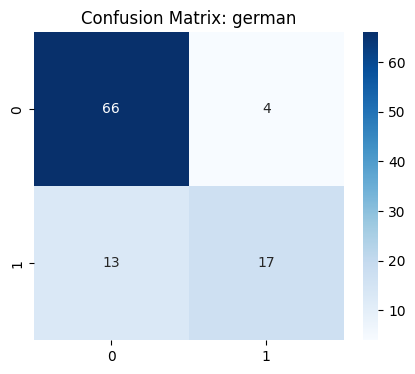

2026-04-23 23:47:31,159 - SHAP failed for german: The shape of the shap_values matrix does not match the shape of the provided data matrix.


<Figure size 640x480 with 0 Axes>

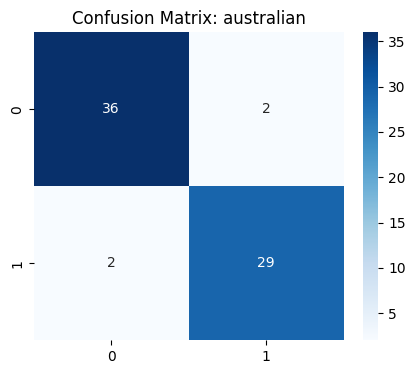

2026-04-23 23:47:35,520 - SHAP failed for australian: The shape of the shap_values matrix does not match the shape of the provided data matrix.


<Figure size 640x480 with 0 Axes>

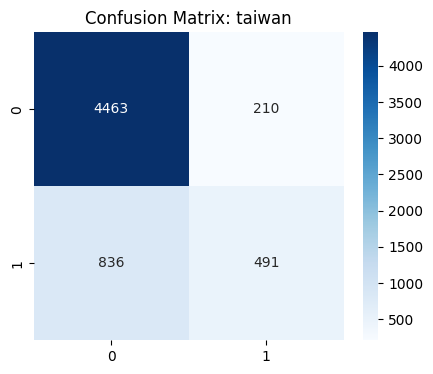

2026-04-23 23:47:41,440 - SHAP failed for taiwan: The shape of the shap_values matrix does not match the shape of the provided data matrix.


<Figure size 640x480 with 0 Axes>

In [24]:
def PlotAnalysis(name, model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_val).to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_val, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.savefig(f'results/plots/cm_{name}.png')
    plt.show()
    
    # 2. SHAP Analysis (Using GradientExplainer for better recurrent/attn support)
    bg_idx = np.random.choice(len(X_val), min(100, len(X_val)), replace=False)
    ts_idx = np.random.choice(len(X_val), min(50, len(X_val)), replace=False)
    
    background = torch.FloatTensor(X_val[bg_idx]).to(DEVICE)
    test_samples = torch.FloatTensor(X_val[ts_idx]).to(DEVICE)
    
    # GradientExplainer is generally more stable than DeepExplainer for GRU/Attention in PyTorch
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(test_samples)
    
    plt.figure()
    # SHAP v0.45+ handling for binary output
    if isinstance(shap_values, list):
        sv = shap_values[0]
    else:
        sv = shap_values
    
    # If SV has 3 dims (samples, seq, feat) due to GRU, flatten for summary plot
    if len(sv.shape) == 3:
        sv = sv.sum(axis=1)
    
    shap.summary_plot(sv, test_samples.cpu().numpy(), show=False)
    plt.title(f'SHAP Summary (Gradient): {name}')
    plt.savefig(f'results/plots/shap_{name}.png')
    plt.show()

for name in all_best_models:
    m, xv, yv = all_best_models[name]
    if m is not None:
        try:
            PlotAnalysis(name, m, xv, yv)
        except Exception as e:
            logger.error(f"SHAP failed for {name}: {e}")